# Two-Asset GBM Spread Option Valuation

This notebook values a two-asset spread option under correlated geometric Brownian motion using:

1. **Kirk's approximation**
2. **Monte Carlo simulation**

The payoff is:

\[
\max(S_1(T) - S_2(T) - K, 0)
\]

Inputs are grouped in one place so you can change:
- initial prices
- volatilities
- time to maturity
- correlation
- strike
- risk-free rate
- Monte Carlo settings

The setup is suitable as a first replication step for the spread-option material in the uploaded deck. 


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log, sqrt, exp, erf

np.set_printoptions(suppress=True, precision=6)

## Inputs

In [3]:
# ===== User inputs =====
S1_0 = 25.0          # initial price of asset 1
S2_0 = 25.0           # initial price of asset 2
sigma1 = 0.45         # volatility of asset 1
sigma2 = 0.45         # volatility of asset 2
rho = 0.95           # correlation between asset returns
T = 10.0              # time to maturity in years
K = 0.0               # strike on the spread
r = 0.0              # continuously compounded risk-free rate

# Monte Carlo controls
n_sims = 200_000
seed = 42

params = pd.Series({
    "S1_0": S1_0,
    "S2_0": S2_0,
    "sigma1": sigma1,
    "sigma2": sigma2,
    "rho": rho,
    "T": T,
    "K": K,
    "r": r,
    "n_sims": n_sims,
    "seed": seed
})
params

S1_0          25.00
S2_0          25.00
sigma1         0.45
sigma2         0.45
rho            0.95
T             10.00
K              0.00
r              0.00
n_sims    200000.00
seed          42.00
dtype: float64

## Helper functions

In [4]:
def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def black76_call(F: float, K: float, sigma: float, T: float, discount: float = 1.0) -> float:
    """
    Black-76 call price on a forward F with strike K.
    If sigma == 0, falls back to intrinsic value.
    """
    if T <= 0:
        return discount * max(F - K, 0.0)
    if sigma <= 0:
        return discount * max(F - K, 0.0)
    if F <= 0 or K <= 0:
        raise ValueError("Black-76 requires positive forward and strike.")

    vol_sqrt_T = sigma * sqrt(T)
    d1 = (log(F / K) + 0.5 * sigma * sigma * T) / vol_sqrt_T
    d2 = d1 - vol_sqrt_T
    return discount * (F * norm_cdf(d1) - K * norm_cdf(d2))

def kirk_spread_option(S1_0, S2_0, K, sigma1, sigma2, rho, T, r=0.0):
    """
    Kirk approximation for a spread call:
        payoff = max(S1(T) - S2(T) - K, 0)

    Under lognormal assumptions and deterministic carry embedded through spot/forward choice.
    For a zero-carry first version, we map spots to forwards with risk-free growth only.
    """
    if S2_0 + K <= 0:
        raise ValueError("Need S2_0 + K > 0 for Kirk approximation.")

    # Forward-style mapping under risk-free growth only
    F1 = S1_0 * exp(r * T)
    F2 = S2_0 * exp(r * T)

    beta = F2 / (F2 + K)
    sigma_kirk = sqrt(sigma1**2 - 2.0 * rho * sigma1 * sigma2 * beta + (sigma2 * beta)**2)

    F = F1
    X = F2 + K
    discount = exp(-r * T)
    price = black76_call(F, X, sigma_kirk, T, discount)

    return {
        "price": price,
        "sigma_kirk": sigma_kirk,
        "F1": F1,
        "F2": F2,
        "effective_strike": X,
        "beta": beta
    }

def monte_carlo_spread_option(S1_0, S2_0, K, sigma1, sigma2, rho, T, r=0.0, n_sims=100_000, seed=42):
    """
    Monte Carlo under correlated GBM:
        dS_i / S_i = r dt + sigma_i dW_i

    Exact terminal simulation:
        S_i(T) = S_i(0) * exp((r - 0.5 sigma_i^2)T + sigma_i sqrt(T) Z_i)
    where corr(Z1, Z2) = rho
    """
    rng = np.random.default_rng(seed)
    z1 = rng.standard_normal(n_sims)
    z_ind = rng.standard_normal(n_sims)
    z2 = rho * z1 + sqrt(max(1.0 - rho**2, 0.0)) * z_ind

    drift1 = (r - 0.5 * sigma1**2) * T
    drift2 = (r - 0.5 * sigma2**2) * T

    S1_T = S1_0 * np.exp(drift1 + sigma1 * sqrt(T) * z1)
    S2_T = S2_0 * np.exp(drift2 + sigma2 * sqrt(T) * z2)

    payoff = np.maximum(S1_T - S2_T - K, 0.0)
    discounted = np.exp(-r * T) * payoff

    price = discounted.mean()
    std_error = discounted.std(ddof=1) / np.sqrt(n_sims)
    ci_low = price - 1.96 * std_error
    ci_high = price + 1.96 * std_error

    return {
        "price": price,
        "std_error": std_error,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "S1_T": S1_T,
        "S2_T": S2_T,
        "payoff": payoff,
        "discounted_payoff": discounted
    }

## Run Kirk and Monte Carlo

In [5]:
kirk = kirk_spread_option(
    S1_0=S1_0,
    S2_0=S2_0,
    K=K,
    sigma1=sigma1,
    sigma2=sigma2,
    rho=rho,
    T=T,
    r=r
)

mc = monte_carlo_spread_option(
    S1_0=S1_0,
    S2_0=S2_0,
    K=K,
    sigma1=sigma1,
    sigma2=sigma2,
    rho=rho,
    T=T,
    r=r,
    n_sims=n_sims,
    seed=seed
)

results = pd.DataFrame({
    "Method": ["Kirk", "Monte Carlo"],
    "Price": [kirk["price"], mc["price"]]
})

results

,Method,Price
0,Kirk,4.450518
1,Monte Carlo,4.565777


In [6]:
a0=kirk_spread_option(S1_0=S1_0,S2_0=S2_0,K=K,sigma1=sigma1,sigma2=sigma2,rho=rho,T=T,r=r)["price"]
a1=kirk_spread_option(S1_0=S1_0,S2_0=S2_0,K=K,sigma1=sigma1,sigma2=sigma2+0.01,rho=rho,T=T,r=r)["price"]
print(a0,a1, (a1-a0))


4.450518143436488 4.509525873113805 0.059007729677317045


In [7]:
diagnostics = pd.Series({
    "Kirk effective volatility": kirk["sigma_kirk"],
    "Kirk beta": kirk["beta"],
    "Monte Carlo std error": mc["std_error"],
    "Monte Carlo 95% CI low": mc["ci_low"],
    "Monte Carlo 95% CI high": mc["ci_high"],
    "Difference (MC - Kirk)": mc["price"] - kirk["price"]
})
diagnostics

Kirk effective volatility    0.142302
Kirk beta                    1.000000
Monte Carlo std error        0.050066
Monte Carlo 95% CI low       4.467647
Monte Carlo 95% CI high      4.663907
Difference (MC - Kirk)       0.115259
dtype: float64

## Quick distribution checks

In [8]:
terminal_df = pd.DataFrame({
    "S1_T": mc["S1_T"],
    "S2_T": mc["S2_T"],
    "Spread_T": mc["S1_T"] - mc["S2_T"],
    "Payoff": mc["payoff"]
})

terminal_df[["S1_T", "S2_T", "Spread_T", "Payoff"]].describe().T

,count,mean,std,min,25%,50%,75%,max
S1_T,200000.0,25.437552,79.948954,0.008175,3.470170,9.044563,23.696325,11291.397999
S2_T,200000.0,25.362251,88.065822,0.009976,3.481859,9.050232,23.742051,20530.595356
Spread_T,200000.0,0.075301,38.738918,-9239.197357,-2.369417,-0.000984,2.381874,2892.246348
Payoff,200000.0,4.565777,22.390268,0.000000,0.000000,0.000000,2.381874,2892.246348


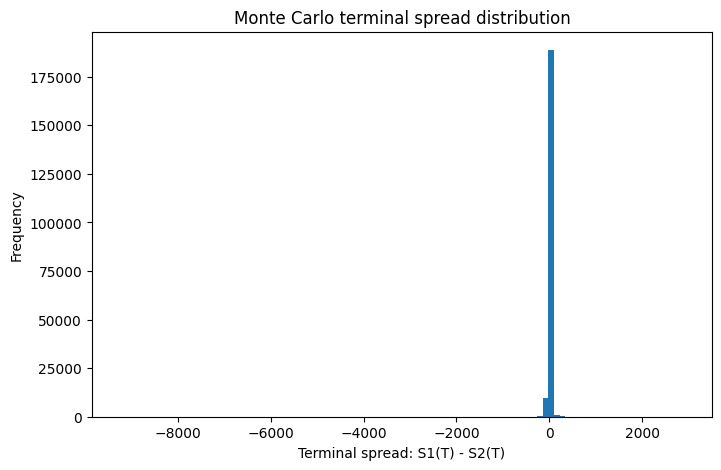

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(terminal_df["Spread_T"], bins=100)
plt.xlabel("Terminal spread: S1(T) - S2(T)")
plt.ylabel("Frequency")
plt.title("Monte Carlo terminal spread distribution")
plt.show()

## Sensitivity example: correlation sweep

Useful for checking how strongly the spread option value reacts to changes in correlation.


In [10]:
rho_grid = np.linspace(-0.9, 0.99, 20)
kirk_prices = []
mc_prices = []

for rho_i in rho_grid:
    kirk_i = kirk_spread_option(S1_0, S2_0, K, sigma1, sigma2, rho_i, T, r)
    mc_i = monte_carlo_spread_option(S1_0, S2_0, K, sigma1, sigma2, rho_i, T, r, n_sims=50_000, seed=seed)
    kirk_prices.append(kirk_i["price"])
    mc_prices.append(mc_i["price"])

corr_df = pd.DataFrame({
    "rho": rho_grid,
    "Kirk": kirk_prices,
    "Monte Carlo": mc_prices
})

corr_df.head()

,rho,Kirk,Monte Carlo
0,-0.900000,20.863904,21.187596
1,-0.800526,20.576183,20.914245
2,-0.701053,20.265119,20.615175
3,-0.601579,19.928275,20.289067
4,-0.502105,19.562847,19.927034


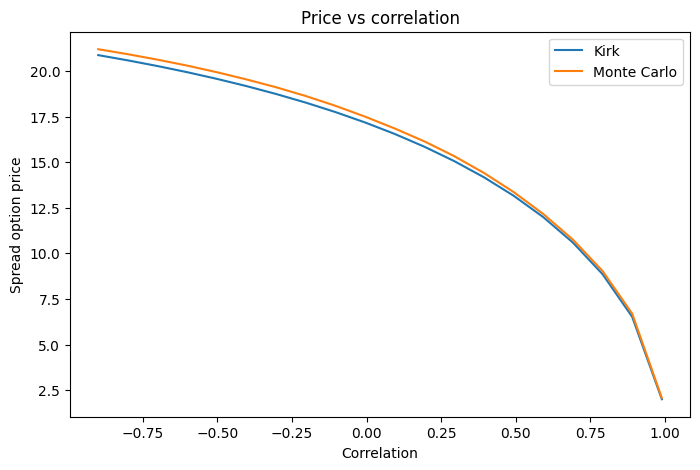

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(corr_df["rho"], corr_df["Kirk"], label="Kirk")
plt.plot(corr_df["rho"], corr_df["Monte Carlo"], label="Monte Carlo")
plt.xlabel("Correlation")
plt.ylabel("Spread option price")
plt.title("Price vs correlation")
plt.legend()
plt.show()

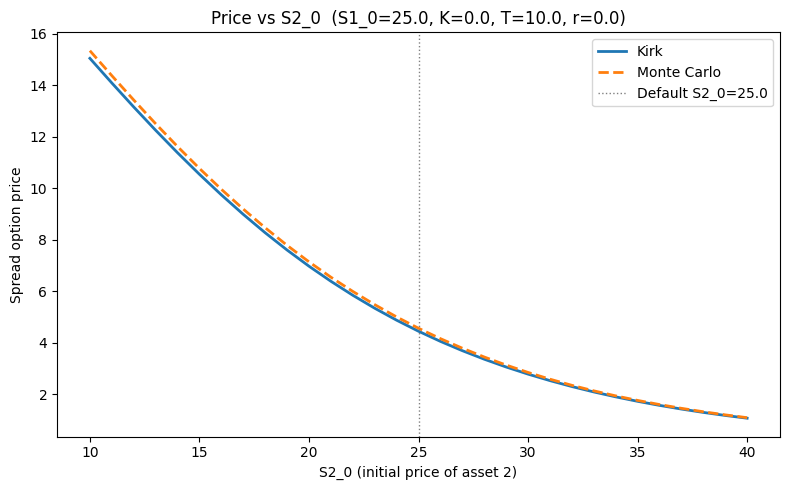

In [12]:
# Sensitivity: option price vs S2_0 (default ± 15)
s2_range = 15
s2_grid = np.linspace(S2_0 - s2_range, S2_0 + s2_range, 31)

kirk_s2, mc_s2 = [], []
for s2 in s2_grid:
    k_res = kirk_spread_option(S1_0, s2, K, sigma1, sigma2, rho, T, r)
    m_res = monte_carlo_spread_option(S1_0, s2, K, sigma1, sigma2, rho, T, r, n_sims=n_sims, seed=seed)
    kirk_s2.append(k_res["price"])
    mc_s2.append(m_res["price"])

kirk_s2, mc_s2 = np.array(kirk_s2), np.array(mc_s2)

plt.figure(figsize=(8, 5))
plt.plot(s2_grid, kirk_s2, label="Kirk", linewidth=2)
plt.plot(s2_grid, mc_s2, label="Monte Carlo", linewidth=2, linestyle="--")
plt.axvline(S2_0, color="grey", linestyle=":", linewidth=1, label=f"Default S2_0={S2_0}")
plt.xlabel("S2_0 (initial price of asset 2)")
plt.ylabel("Spread option price")
plt.title(f"Price vs S2_0  (S1_0={S1_0}, K={K}, T={T}, r={r})")
plt.legend()
plt.tight_layout()
plt.show()


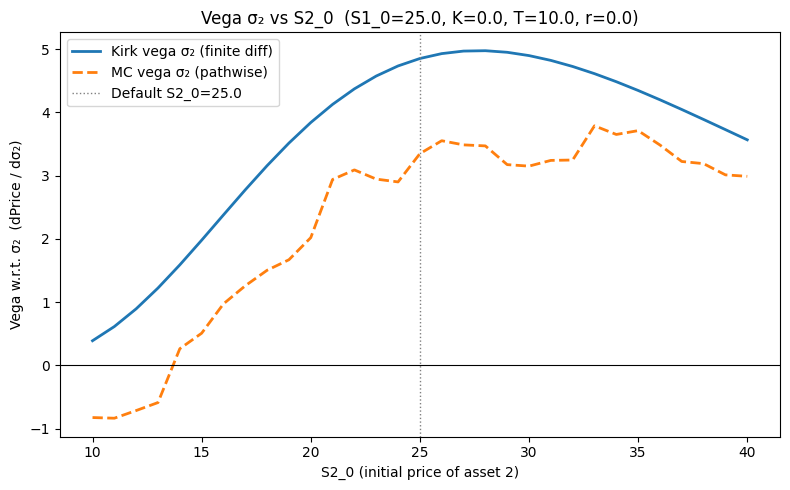

In [13]:
# Vega w.r.t. sigma2 vs S2_0
# Kirk: central finite difference on analytic formula (exact for K=0 Margrabe).
# MC: pathwise estimator — no finite-difference noise.
#   d/dsigma2 E[max(S1-S2-K,0)] via chain rule on the log-price:
#   d(S2_T)/d(sigma2) = S2_T * (-sigma2*T + sqrt(T)*z2)  [from log S2_T]
#   pathwise vega = E[ -d(S2_T)/d(sigma2) * 1_{S1_T > S2_T + K} ] * disc

bump = 0.01

kirk_vega_s2, mc_vega_s2 = [], []
for s2 in s2_grid:
    # Kirk: analytic finite difference (smooth, no noise)
    k_up = kirk_spread_option(S1_0, s2, K, sigma1, sigma2 + bump, rho, T, r)["price"]
    k_dn = kirk_spread_option(S1_0, s2, K, sigma1, sigma2 - bump, rho, T, r)["price"]
    kirk_vega_s2.append((k_up - k_dn) / (2 * bump))

    # MC: pathwise estimator (no bump noise)
    rng = np.random.default_rng(seed)
    z1 = rng.standard_normal(n_sims)
    z_ind = rng.standard_normal(n_sims)
    z2 = rho * z1 + sqrt(max(1.0 - rho**2, 0.0)) * z_ind

    S1_T = S1_0 * np.exp((r - 0.5 * sigma1**2) * T + sigma1 * sqrt(T) * z1)
    S2_T = s2  * np.exp((r - 0.5 * sigma2**2) * T + sigma2 * sqrt(T) * z2)

    itm = S1_T > S2_T + K                              # indicator 1{in the money}
    dS2_dsigma2 = S2_T * (-sigma2 * T + sqrt(T) * z2)  # d(S2_T)/d(sigma2)
    disc = np.exp(-r * T)
    vega_paths = disc * (-dS2_dsigma2) * itm           # chain rule: payoff increases when S2 falls
    mc_vega_s2.append(vega_paths.mean())

kirk_vega_s2, mc_vega_s2 = np.array(kirk_vega_s2), np.array(mc_vega_s2)

plt.figure(figsize=(8, 5))
plt.plot(s2_grid, kirk_vega_s2, label="Kirk vega σ₂ (finite diff)", linewidth=2)
plt.plot(s2_grid, mc_vega_s2, label="MC vega σ₂ (pathwise)", linewidth=2, linestyle="--")
plt.axvline(S2_0, color="grey", linestyle=":", linewidth=1, label=f"Default S2_0={S2_0}")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("S2_0 (initial price of asset 2)")
plt.ylabel("Vega w.r.t. σ₂  (dPrice / dσ₂)")
plt.title(f"Vega σ₂ vs S2_0  (S1_0={S1_0}, K={K}, T={T}, r={r})")
plt.legend()
plt.tight_layout()
plt.show()


Hedge ratio  h = -0.1912  (averaged over S2_0 ± 5)
Spread vega  at S2_0: 4.8499
Put vega     at S2_0: 24.4861
Portfolio vega at S2_0: 0.1672
Mean portfolio vega over band: 0.000000


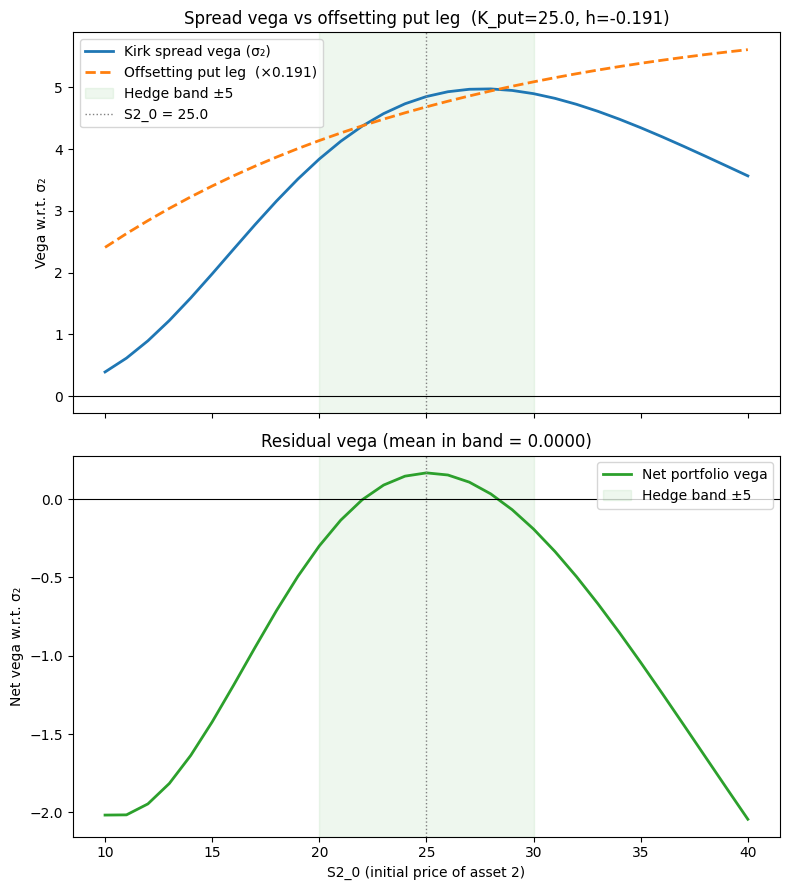

In [14]:
# Portfolio: 1 spread option + h vanilla puts on S2
# Strike of put = S2_0 (ATM at inception), same T, r, sigma2.
# h chosen so mean residual vega over S2_0 ± 5 is zero.
# Note: European put vega = call vega (put-call parity), so h is identical to the call case.

def bs_put_price(S, K_put, sigma, T, r):
    if T <= 0 or sigma <= 0 or S <= 0 or K_put <= 0:
        return max(K_put * exp(-r * T) - S, 0.0)
    d1 = (log(S / K_put) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return K_put * exp(-r * T) * norm_cdf(-d2) - S * norm_cdf(-d1)

def bs_put_vega(S, K_put, sigma, T, r, bump=0.001):
    """dPrice/dsigma for a vanilla put (equals call vega by put-call parity)."""
    return (bs_put_price(S, K_put, sigma + bump, T, r)
          - bs_put_price(S, K_put, sigma - bump, T, r)) / (2 * bump)

K_put = S2_0    # ATM put strike, fixed at inception
hedge_band = 5  # average residual vega to zero over S2_0 ± this

vega_put_grid = np.array([bs_put_vega(s2, K_put, sigma2, T, r) for s2 in s2_grid])

mask = np.abs(s2_grid - S2_0) <= hedge_band
h = -kirk_vega_s2[mask].mean() / vega_put_grid[mask].mean()

portfolio_vega = kirk_vega_s2 + h * vega_put_grid

idx0 = np.argmin(np.abs(s2_grid - S2_0))
print(f"Hedge ratio  h = {h:.4f}  (averaged over S2_0 ± {hedge_band})")
print(f"Spread vega  at S2_0: {kirk_vega_s2[idx0]:.4f}")
print(f"Put vega     at S2_0: {vega_put_grid[idx0]:.4f}")
print(f"Portfolio vega at S2_0: {portfolio_vega[idx0]:.4f}")
print(f"Mean portfolio vega over band: {portfolio_vega[mask].mean():.6f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), sharex=True)

ax1.plot(s2_grid, kirk_vega_s2,       label="Kirk spread vega (σ₂)", linewidth=2)
ax1.plot(s2_grid, -h * vega_put_grid, label=f"Offsetting put leg  (×{-h:.3f})", linewidth=2, linestyle="--")
ax1.axvspan(S2_0 - hedge_band, S2_0 + hedge_band, alpha=0.08, color="C2", label=f"Hedge band ±{hedge_band}")
ax1.axvline(S2_0, color="grey", linestyle=":", linewidth=1, label=f"S2_0 = {S2_0}")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_ylabel("Vega w.r.t. σ₂")
ax1.set_title(f"Spread vega vs offsetting put leg  (K_put={K_put}, h={h:.3f})")
ax1.legend()

ax2.plot(s2_grid, portfolio_vega, color="C2", linewidth=2, label="Net portfolio vega")
ax2.axvspan(S2_0 - hedge_band, S2_0 + hedge_band, alpha=0.08, color="C2", label=f"Hedge band ±{hedge_band}")
ax2.axvline(S2_0, color="grey", linestyle=":", linewidth=1)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlabel("S2_0 (initial price of asset 2)")
ax2.set_ylabel("Net vega w.r.t. σ₂")
ax2.set_title(f"Residual vega (mean in band = {portfolio_vega[mask].mean():.4f})")
ax2.legend()

plt.tight_layout()
plt.show()


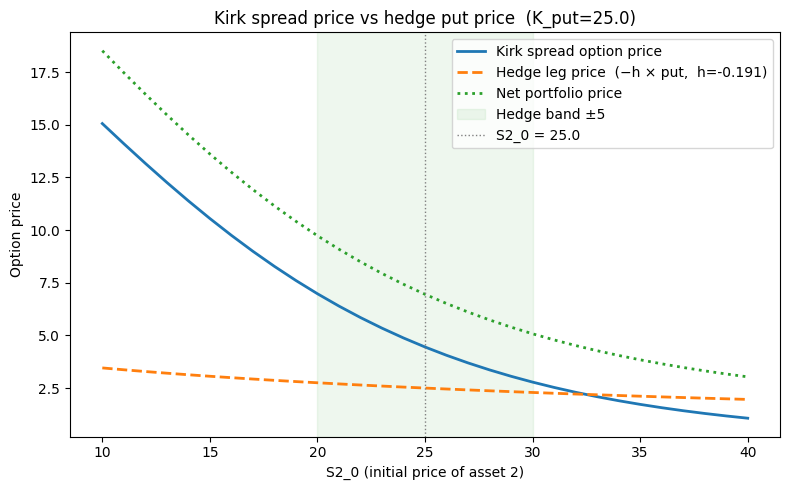

In [15]:
# Price of Kirk spread option vs hedge put leg over S2_grid
kirk_price_grid = np.array([
    kirk_spread_option(S1_0, s2, K, sigma1, sigma2, rho, T, r)["price"]
    for s2 in s2_grid
])

put_price_grid  = np.array([bs_put_price(s2, K_put, sigma2, T, r) for s2 in s2_grid])
hedge_price_grid = -h * put_price_grid   # cost of the short-put hedge leg

plt.figure(figsize=(8, 5))
plt.plot(s2_grid, kirk_price_grid,                        label="Kirk spread option price", linewidth=2)
plt.plot(s2_grid, hedge_price_grid,                       label=f"Hedge leg price  (−h × put,  h={h:.3f})", linewidth=2, linestyle="--")
plt.plot(s2_grid, kirk_price_grid + hedge_price_grid,     label="Net portfolio price", linewidth=2, linestyle=":")
plt.axvspan(S2_0 - hedge_band, S2_0 + hedge_band, alpha=0.08, color="C2", label=f"Hedge band ±{hedge_band}")
plt.axvline(S2_0, color="grey", linestyle=":", linewidth=1, label=f"S2_0 = {S2_0}")
plt.xlabel("S2_0 (initial price of asset 2)")
plt.ylabel("Option price")
plt.title(f"Kirk spread price vs hedge put price  (K_put={K_put})")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
put_price = 0.191*bs_put_price(S=25, K_put=25, sigma=0.45, T=10, r=0)
print(f"Put price: {put_price:.4f}")


Put price: 2.4984


## Vega Hedge: OTM Strangle (Call@35 + Put@15, equal size)

Replace the ATM put with **equal numbers** of:
- long call on S₂ with K_call = 35 (OTM call)
- long put  on S₂ with K_put  = 15 (OTM put)

Same T, r, σ₂ as the spread option. Hedge size **h** chosen so net vega (w.r.t. σ₂) averages to zero over S₂₀ ± hedge_band.

Because call vega = put vega at the same strike (put-call parity), the two OTM wings contribute different amounts; we treat the pair as a unit and solve for one scalar h.


In [17]:
def bs_call_price(S, K_call, sigma, T, r):
    if T <= 0 or sigma <= 0 or S <= 0 or K_call <= 0:
        return max(S - K_call * exp(-r * T), 0.0)
    d1 = (log(S / K_call) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S * norm_cdf(d1) - K_call * exp(-r * T) * norm_cdf(d2)

def bs_vega(S, K, sigma, T, r, bump=0.001):
    """dPrice/dsigma for a vanilla European option (call vega == put vega by parity)."""
    return (bs_call_price(S, K, sigma + bump, T, r)
          - bs_call_price(S, K, sigma - bump, T, r)) / (2 * bump)

K_call_hedge = 45.0   # OTM call strike
K_put_hedge  = 10.0   # OTM put  strike

# Strangle vega across S2 grid (call@35 vega + put@15 vega; put vega == call vega)
strangle_vega_grid = np.array([
    bs_vega(s2, K_call_hedge, sigma2, T, r) + bs_vega(s2, K_put_hedge, sigma2, T, r)
    for s2 in s2_grid
])

# Solve for h: spread_vega + h * strangle_vega = 0, averaged over hedge band
h_strangle = -kirk_vega_s2[mask].mean() / strangle_vega_grid[mask].mean()

portfolio_vega_strangle = kirk_vega_s2 + h_strangle * strangle_vega_grid

print(f"Hedge legs:  long call @ K={K_call_hedge},  long put @ K={K_put_hedge},  equal size h")
print(f"Hedge ratio  h = {h_strangle:.4f}  (averaged over S2_0 ± {hedge_band})")
print(f"Spread  vega  at S2_0={S2_0}: {kirk_vega_s2[idx0]:.4f}")
print(f"Strangle vega at S2_0={S2_0}: {strangle_vega_grid[idx0]:.4f}")
print(f"  of which call@{K_call_hedge}:  {bs_vega(S2_0, K_call_hedge, sigma2, T, r):.4f}")
print(f"  of which put@{K_put_hedge}:   {bs_vega(S2_0, K_put_hedge,  sigma2, T, r):.4f}")
print(f"Portfolio vega at S2_0={S2_0}: {portfolio_vega_strangle[idx0]:.4f}")
print(f"Mean portfolio vega over band:  {portfolio_vega_strangle[mask].mean():.6f}")


Hedge legs:  long call @ K=45.0,  long put @ K=10.0,  equal size h
Hedge ratio  h = -0.1094  (averaged over S2_0 ± 5)
Spread  vega  at S2_0=25.0: 4.8499
Strangle vega at S2_0=25.0: 42.7521
  of which call@45.0:  30.1652
  of which put@10.0:   12.5868
Portfolio vega at S2_0=25.0: 0.1718
Mean portfolio vega over band:  0.000000


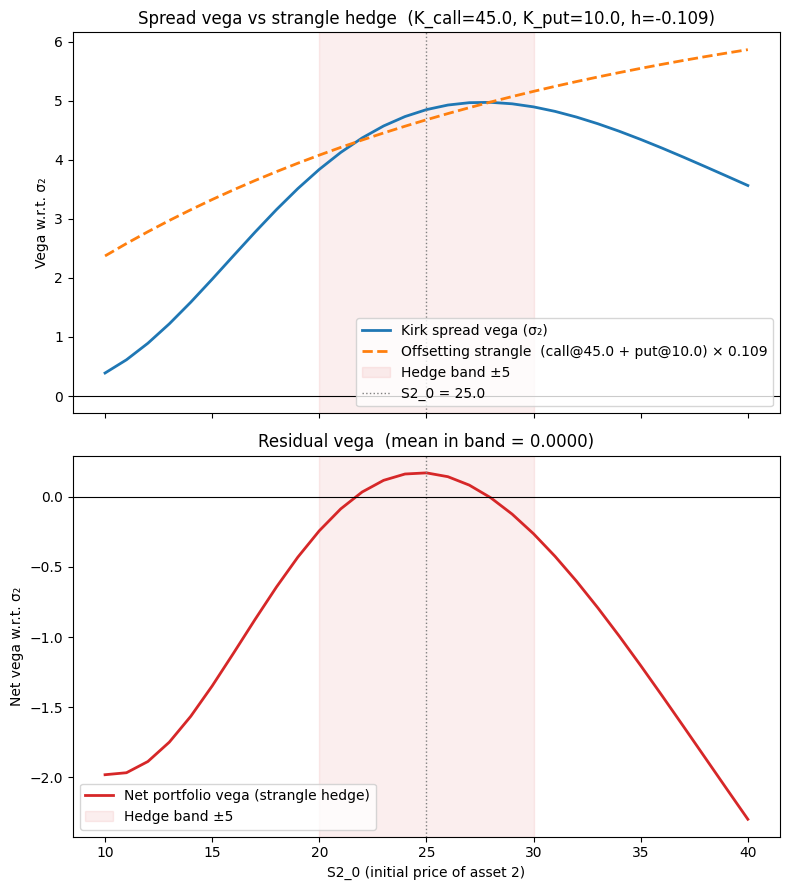

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), sharex=True)

ax1.plot(s2_grid, kirk_vega_s2,
         label="Kirk spread vega (σ₂)", linewidth=2)
ax1.plot(s2_grid, -h_strangle * strangle_vega_grid,
         label=f"Offsetting strangle  (call@{K_call_hedge} + put@{K_put_hedge}) × {-h_strangle:.3f}",
         linewidth=2, linestyle="--")
ax1.axvspan(S2_0 - hedge_band, S2_0 + hedge_band, alpha=0.08, color="C3",
            label=f"Hedge band ±{hedge_band}")
ax1.axvline(S2_0, color="grey", linestyle=":", linewidth=1, label=f"S2_0 = {S2_0}")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_ylabel("Vega w.r.t. σ₂")
ax1.set_title(f"Spread vega vs strangle hedge  "
              f"(K_call={K_call_hedge}, K_put={K_put_hedge}, h={h_strangle:.3f})")
ax1.legend()

ax2.plot(s2_grid, portfolio_vega_strangle, color="C3", linewidth=2,
         label="Net portfolio vega (strangle hedge)")
ax2.axvspan(S2_0 - hedge_band, S2_0 + hedge_band, alpha=0.08, color="C3",
            label=f"Hedge band ±{hedge_band}")
ax2.axvline(S2_0, color="grey", linestyle=":", linewidth=1)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlabel("S2_0 (initial price of asset 2)")
ax2.set_ylabel("Net vega w.r.t. σ₂")
ax2.set_title(f"Residual vega  (mean in band = {portfolio_vega_strangle[mask].mean():.4f})")
ax2.legend()

plt.tight_layout()
plt.show()


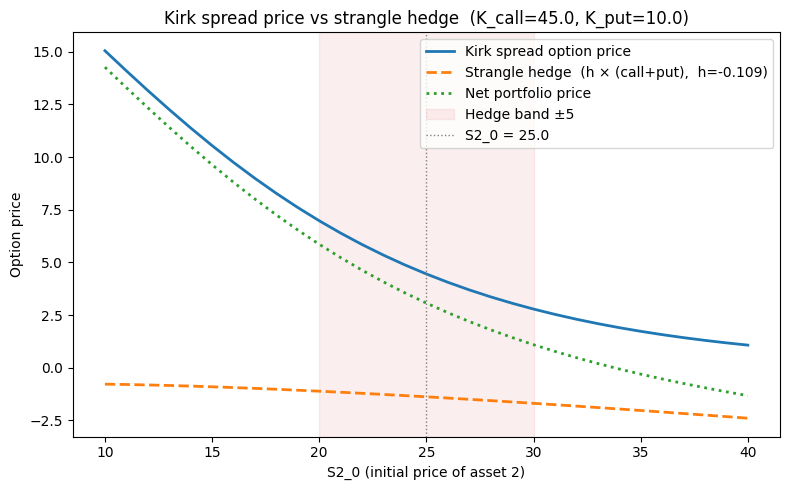


At S2_0 = 25.0
Spread option price (Kirk)     4.450518
Call@45.0 price                9.565696
Put@10.0 price                 3.078452
Strangle price (call+put)     12.644149
Hedge ratio h                 -0.109424
Hedge cost (h × strangle)     -1.383575
Net portfolio cost             3.066943


In [19]:
# Price profile: spread option + strangle hedge
call_price_grid   = np.array([bs_call_price(s2, K_call_hedge, sigma2, T, r) for s2 in s2_grid])
put_price_grid2   = np.array([bs_put_price(s2,  K_put_hedge,  sigma2, T, r) for s2 in s2_grid])
strangle_price_grid  = call_price_grid + put_price_grid2
hedge_strangle_price = h_strangle * strangle_price_grid

plt.figure(figsize=(8, 5))
plt.plot(s2_grid, kirk_price_grid,
         label="Kirk spread option price", linewidth=2)
plt.plot(s2_grid, hedge_strangle_price,
         label=f"Strangle hedge  (h × (call+put),  h={h_strangle:.3f})", linewidth=2, linestyle="--")
plt.plot(s2_grid, kirk_price_grid + hedge_strangle_price,
         label="Net portfolio price", linewidth=2, linestyle=":")
plt.axvspan(S2_0 - hedge_band, S2_0 + hedge_band, alpha=0.08, color="C3",
            label=f"Hedge band ±{hedge_band}")
plt.axvline(S2_0, color="grey", linestyle=":", linewidth=1, label=f"S2_0 = {S2_0}")
plt.xlabel("S2_0 (initial price of asset 2)")
plt.ylabel("Option price")
plt.title(f"Kirk spread price vs strangle hedge  "
          f"(K_call={K_call_hedge}, K_put={K_put_hedge})")
plt.legend()
plt.tight_layout()
plt.show()

# Summary table at S2_0
strangle_price_at_S20 = bs_call_price(S2_0, K_call_hedge, sigma2, T, r) + bs_put_price(S2_0, K_put_hedge, sigma2, T, r)
summary = pd.Series({
    "Spread option price (Kirk)":        kirk_price_grid[idx0],
    f"Call@{K_call_hedge} price":              bs_call_price(S2_0, K_call_hedge, sigma2, T, r),
    f"Put@{K_put_hedge} price":               bs_put_price(S2_0,  K_put_hedge,  sigma2, T, r),
    "Strangle price (call+put)":         strangle_price_at_S20,
    "Hedge ratio h":                     h_strangle,
    "Hedge cost (h × strangle)":         h_strangle * strangle_price_at_S20,
    "Net portfolio cost":                kirk_price_grid[idx0] + h_strangle * strangle_price_at_S20,
})
print("\nAt S2_0 =", S2_0)
print(summary.to_string())


## Optimal Static Hedge: ATM Call1 + ATM Put2 + Futures

**Instruments:** long spread option + h1 × Call1(K=S₁₀) + h2 × Put2(K=S₂₀) + nF1 × F1 + nF2 × F2

**Min problem:** minimise integrated squared residual Greeks (Δ, Γ, ν) over a 2-D grid of (S₁, S₂), with each Greek normalised by its inception value so delta, gamma, vega contribute equally:

$$\min_{h_1,\,nF_1,\,h_2,\,nF_2} \sum_{S_1,S_2} \left[\frac{(r_{\Delta_1})^2 + (r_{\Delta_2})^2}{\sigma_\Delta^2} + \frac{(r_{\Gamma_{11}})^2 + (r_{\Gamma_{22}})^2}{\sigma_\Gamma^2} + \frac{(r_{\nu_1})^2 + (r_{\nu_2})^2}{\sigma_\nu^2}\right]$$

**Key structural property:** Call1 only enters Δ₁/Γ₁₁/ν₁ and Put2 only enters Δ₂/Γ₂₂/ν₂, so the 4-variable problem decomposes into two independent 2-variable least-squares sub-problems — each solved in one shot with `numpy.linalg.lstsq`.

**Γ₁₂ = ∂²P/∂S₁∂S₂ (cross-gamma) is structurally unhedgeable** with any combination of single-asset instruments.


In [20]:
from scipy.stats import norm as _snm

_N, _Np = _snm.cdf, _snm.pdf                           # vectorised CDF and PDF
_sk  = sqrt(sigma1**2 - 2*rho*sigma1*sigma2 + sigma2**2)  # Margrabe effective vol (K=0, constant)
_sqT = sqrt(T)

# ── Vectorised Greeks ────────────────────────────────────────────────────────

def _sp_gk(S1, S2):
    """Spread option (Margrabe K=0) Greeks — arrays in, dict of arrays out."""
    F1, F2, D = S1*exp(r*T), S2*exp(r*T), exp(-r*T)
    d1 = np.log(F1/F2)/(_sk*_sqT) + 0.5*_sk*_sqT
    d2 = d1 - _sk*_sqT
    np1, np2 = _Np(d1), _Np(d2)
    vk = D*F1*np1*_sqT                                 # dP/d(sigma_kirk)
    return {
        "d1" :  D*_N(d1),                              # ∂P/∂S1
        "d2" : -D*_N(d2),                              # ∂P/∂S2
        "g11":  D*np1/(F1*_sk*_sqT),                   # ∂²P/∂S1²
        "g22":  D*np2/(F2*_sk*_sqT),                   # ∂²P/∂S2²
        "g12": -D*np1/(F2*_sk*_sqT),                   # cross-gamma (unhedgeable)
        "v1" :  vk*(sigma1 - rho*sigma2)/_sk,          # ∂P/∂σ1
        "v2" :  vk*(sigma2 - rho*sigma1)/_sk,          # ∂P/∂σ2
    }

def _c1_gk(S1, K):
    """BS call on S1 Greeks — vectorised."""
    d1 = (np.log(S1/K) + (r + 0.5*sigma1**2)*T) / (sigma1*_sqT)
    np1 = _Np(d1)
    return {"d1": _N(d1), "g11": np1/(S1*sigma1*_sqT), "v1": S1*np1*_sqT}

def _p2_gk(S2, K):
    """BS put on S2 Greeks — vectorised."""
    d1 = (np.log(S2/K) + (r + 0.5*sigma2**2)*T) / (sigma2*_sqT)
    np1 = _Np(d1)
    return {"d2": _N(d1) - 1., "g22": np1/(S2*sigma2*_sqT), "v2": S2*np1*_sqT}

# ── Least-squares grid ───────────────────────────────────────────────────────

K1h, K2h = S1_0, S2_0                                  # ATM call on S1, ATM put on S2
N_OLS    = 35
s1_o, s2_o = np.linspace(10, 50, N_OLS), np.linspace(10, 50, N_OLS)
S1o, S2o   = np.meshgrid(s1_o, s2_o)
s1f, s2f   = S1o.ravel(), S2o.ravel()

sp = _sp_gk(s1f, s2f)
c1 = _c1_gk(s1f, K1h)
p2 = _p2_gk(s2f, K2h)

# Normalise by inception values so Δ, Γ, ν each contribute equally
# Pass plain Python floats — np.array([x]) returns shape-(1,) which float() rejects
g0   = {k: float(np.squeeze(v)) for k, v in _sp_gk(S1_0, S2_0).items()}
sc_d = max(abs(g0["d1"]),  1e-12)
sc_g = max(abs(g0["g11"]), 1e-12)
sc_v = max(abs(g0["v1"]),  1e-12)

# ── Decoupled OLS solver ─────────────────────────────────────────────────────
# Objective splits: J(h1,nF1) + J(h2,nF2) because Call1 and Put2 touch
# disjoint Greek blocks.  Each sub-problem is a linear least-squares:
#
#   [inst_d/sc_d  1/sc_d] [h ]   [-sp_d/sc_d ]   (delta block, nF enters)
#   [inst_g/sc_g  0     ] [nF] = [-sp_g/sc_g ]   (gamma block)
#   [inst_v/sc_v  0     ]        [-sp_v/sc_v ]   (vega  block)

def _ols_pair(sp_d, sp_g, sp_v, inst_d, inst_g, inst_v):
    n = len(sp_d)
    A = np.zeros((3*n, 2));  b = np.zeros(3*n)
    A[:n,    0], A[:n,    1] = inst_d/sc_d, np.ones(n)/sc_d;  b[:n]    = -sp_d/sc_d
    A[n:2*n, 0]              = inst_g/sc_g;                    b[n:2*n] = -sp_g/sc_g
    A[2*n:,  0]              = inst_v/sc_v;                    b[2*n:]  = -sp_v/sc_v
    return np.linalg.lstsq(A, b, rcond=None)[0]

h1_opt, nF1_opt = _ols_pair(sp["d1"], sp["g11"], sp["v1"], c1["d1"], c1["g11"], c1["v1"])
h2_opt, nF2_opt = _ols_pair(sp["d2"], sp["g22"], sp["v2"], p2["d2"], p2["g22"], p2["v2"])

print(f"Optimal static hedge  (OLS, S1/S2 ∈ [{s1_o[0]:.0f}, {s1_o[-1]:.0f}]):")
print(f"  h1  (Call1 @ K={K1h:.0f})   = {h1_opt:+.4f}")
print(f"  nF1 (Future1 position)    = {nF1_opt:+.4f}")
print(f"  h2  (Put2  @ K={K2h:.0f})   = {h2_opt:+.4f}")
print(f"  nF2 (Future2 position)    = {nF2_opt:+.4f}")

# ── Residuals at inception ────────────────────────────────────────────────────
c1_0 = {k: float(np.squeeze(v)) for k, v in _c1_gk(S1_0, K1h).items()}
p2_0 = {k: float(np.squeeze(v)) for k, v in _p2_gk(S2_0, K2h).items()}

res_at_0 = {
    "Δ₁"  : g0["d1"]  + h1_opt*c1_0["d1"]  + nF1_opt,
    "Δ₂"  : g0["d2"]  + h2_opt*p2_0["d2"]  + nF2_opt,
    "Γ₁₁" : g0["g11"] + h1_opt*c1_0["g11"],
    "Γ₂₂" : g0["g22"] + h2_opt*p2_0["g22"],
    "Γ₁₂" : g0["g12"],                         # always unhedged
    "ν₁"  : g0["v1"]  + h1_opt*c1_0["v1"],
    "ν₂"  : g0["v2"]  + h2_opt*p2_0["v2"],
}
print(f"\nResiduals at inception (S1={S1_0}, S2={S2_0}):")
for name, val in res_at_0.items():
    note = "  ← unhedgeable" if name == "Γ₁₂" else ""
    print(f"  {name} : {val:+.6f}{note}")


Optimal static hedge  (OLS, S1/S2 ∈ [10, 50]):
  h1  (Call1 @ K=25)   = -0.1509
  nF1 (Future1 position)    = -0.4349
  h2  (Put2  @ K=25)   = -0.1509
  nF2 (Future2 position)    = +0.4142

Residuals at inception (S1=25.0, S2=25.0):
  Δ₁ : +0.039149
  Δ₂ : +0.039149
  Γ₁₁ : +0.033261
  Γ₂₂ : +0.033261
  Γ₁₂ : -0.034575  ← unhedgeable
  ν₁ : +1.166253
  ν₂ : +1.166253


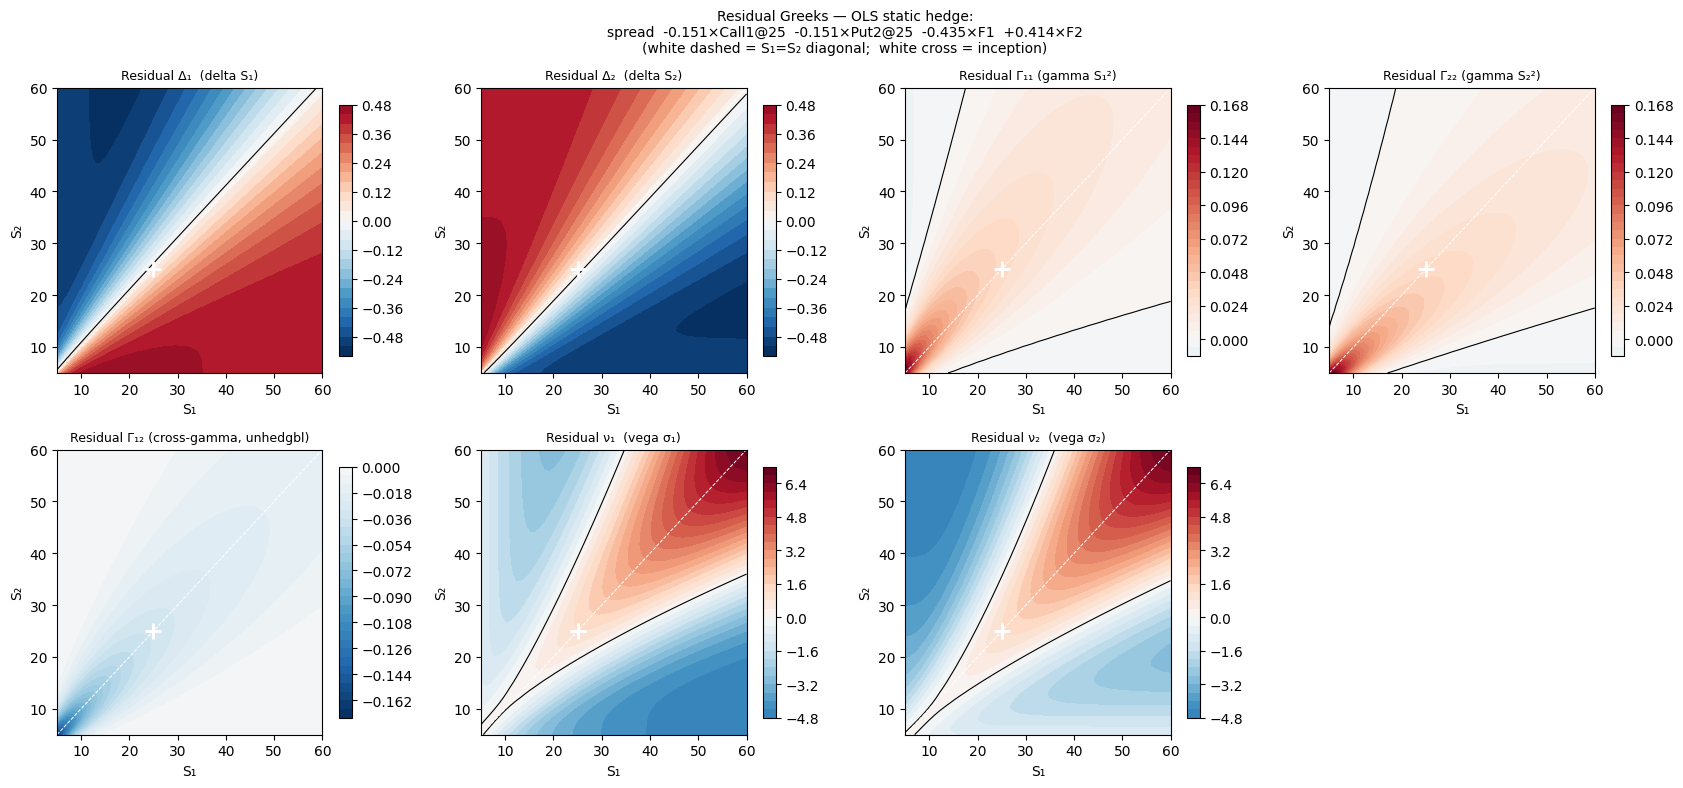

In [21]:
# ── Fine grid for residual maps ──────────────────────────────────────────────
N_PLT = 55
s1_p, s2_p = np.linspace(5, 60, N_PLT), np.linspace(5, 60, N_PLT)
S1P, S2P   = np.meshgrid(s1_p, s2_p)
s1pf, s2pf = S1P.ravel(), S2P.ravel()

spp = _sp_gk(s1pf, s2pf)
c1p = _c1_gk(s1pf, K1h)
p2p = _p2_gk(s2pf, K2h)

residuals = {
    "Δ₁  (delta S₁)"            : (spp["d1"]  + h1_opt*c1p["d1"]  + nF1_opt).reshape(N_PLT, N_PLT),
    "Δ₂  (delta S₂)"            : (spp["d2"]  + h2_opt*p2p["d2"]  + nF2_opt).reshape(N_PLT, N_PLT),
    "Γ₁₁ (gamma S₁²)"           : (spp["g11"] + h1_opt*c1p["g11"]           ).reshape(N_PLT, N_PLT),
    "Γ₂₂ (gamma S₂²)"           : (spp["g22"] + h2_opt*p2p["g22"]           ).reshape(N_PLT, N_PLT),
    "Γ₁₂ (cross-gamma, unhedgbl)": spp["g12"]                                 .reshape(N_PLT, N_PLT),
    "ν₁  (vega σ₁)"             : (spp["v1"]  + h1_opt*c1p["v1"]            ).reshape(N_PLT, N_PLT),
    "ν₂  (vega σ₂)"             : (spp["v2"]  + h2_opt*p2p["v2"]            ).reshape(N_PLT, N_PLT),
}

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.ravel()

for ax, (label, Z) in zip(axes, residuals.items()):
    vm = max(np.abs(Z).max(), 1e-12)
    cf = ax.contourf(S1P, S2P, Z, levels=30, cmap="RdBu_r", vmin=-vm, vmax=vm)
    ax.contour(S1P, S2P, Z, levels=[0], colors="k", linewidths=0.8)
    ax.plot([5, 60], [5, 60], "w--", lw=0.7, label="S₁=S₂")     # ATM diagonal
    ax.plot(S1_0, S2_0, "w+", ms=11, mew=2.0, label=f"inception ({S1_0},{S2_0})")
    plt.colorbar(cf, ax=ax, shrink=0.88)
    ax.set_title(f"Residual {label}", fontsize=9)
    ax.set_xlabel("S₁")
    ax.set_ylabel("S₂")

axes[-1].set_visible(False)   # hide 8th panel

plt.suptitle(
    f"Residual Greeks — OLS static hedge:\n"
    f"spread  {h1_opt:+.3f}×Call1@{K1h:.0f}  {h2_opt:+.3f}×Put2@{K2h:.0f}"
    f"  {nF1_opt:+.3f}×F1  {nF2_opt:+.3f}×F2\n"
    f"(white dashed = S₁=S₂ diagonal;  white cross = inception)",
    fontsize=10
)
plt.tight_layout()
plt.show()


Prices at inception  (S1=25.0, S2=25.0):
  Spread option                = +4.4505
  Call1 @ K=25  (raw price)   = +13.0808
  Put2  @ K=25  (raw price)   = +13.0808
  h1 × Call1  (hedge leg)      = -1.9744   (h1=-0.1509)
  h2 × Put2   (hedge leg)      = -1.9744   (h2=-0.1509)
  Net portfolio (options only) = +0.5017


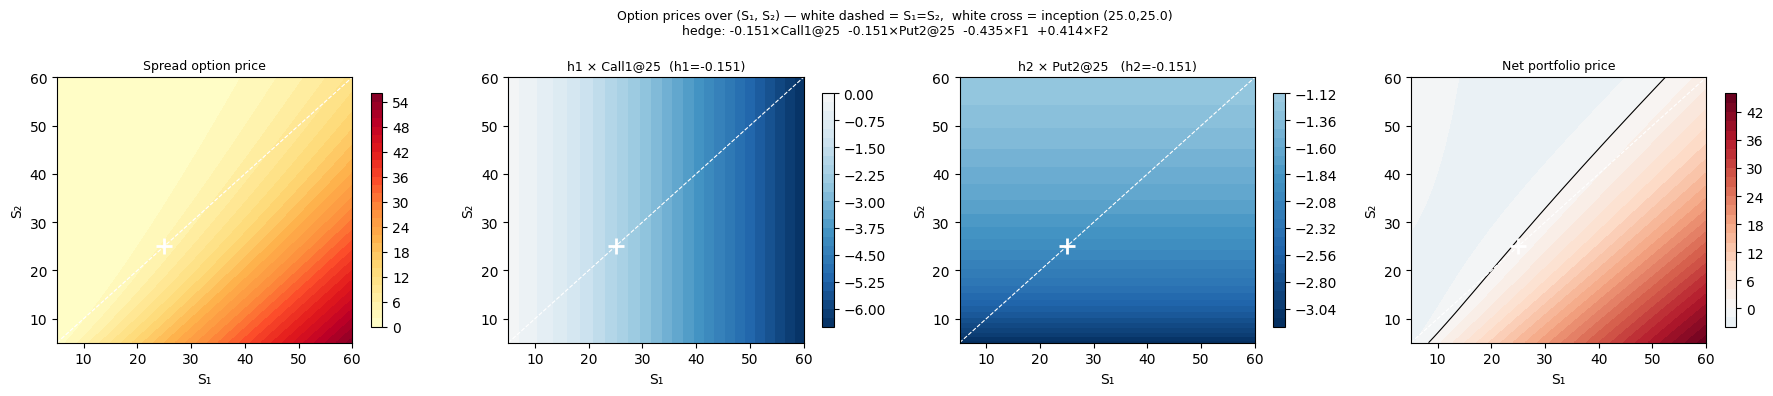

In [22]:
# ── Vectorised price functions ───────────────────────────────────────────────

def _sp_price(S1, S2):
    F1, F2, D = S1*exp(r*T), S2*exp(r*T), exp(-r*T)
    d1 = np.log(F1/F2)/(_sk*_sqT) + 0.5*_sk*_sqT
    d2 = d1 - _sk*_sqT
    return D*(F1*_N(d1) - F2*_N(d2))

def _c1_price(S1, K):
    d1 = (np.log(S1/K) + (r + 0.5*sigma1**2)*T) / (sigma1*_sqT)
    d2 = d1 - sigma1*_sqT
    return S1*_N(d1) - K*exp(-r*T)*_N(d2)

def _p2_price(S2, K):
    d1 = (np.log(S2/K) + (r + 0.5*sigma2**2)*T) / (sigma2*_sqT)
    d2 = d1 - sigma2*_sqT
    return K*exp(-r*T)*_N(-d2) - S2*_N(-d1)

# ── Compute prices on the fine plot grid ─────────────────────────────────────
P_spread = _sp_price(s1pf, s2pf).reshape(N_PLT, N_PLT)
P_call1  = _c1_price(s1pf, K1h).reshape(N_PLT, N_PLT)
P_put2   = _p2_price(s2pf, K2h).reshape(N_PLT, N_PLT)
P_net    = P_spread + h1_opt*P_call1 + h2_opt*P_put2   # futures carry zero premium

# Inception-point prices (for the printed table)
p0_sp  = float(np.squeeze(_sp_price(S1_0, S2_0)))
p0_c1  = float(np.squeeze(_c1_price(S1_0, K1h)))
p0_p2  = float(np.squeeze(_p2_price(S2_0, K2h)))
p0_net = p0_sp + h1_opt*p0_c1 + h2_opt*p0_p2

print(f"Prices at inception  (S1={S1_0}, S2={S2_0}):")
print(f"  Spread option                = {p0_sp:+.4f}")
print(f"  Call1 @ K={K1h:.0f}  (raw price)   = {p0_c1:+.4f}")
print(f"  Put2  @ K={K2h:.0f}  (raw price)   = {p0_p2:+.4f}")
print(f"  h1 × Call1  (hedge leg)      = {h1_opt*p0_c1:+.4f}   (h1={h1_opt:+.4f})")
print(f"  h2 × Put2   (hedge leg)      = {h2_opt*p0_p2:+.4f}   (h2={h2_opt:+.4f})")
print(f"  Net portfolio (options only) = {p0_net:+.4f}")

# ── 2-D price maps ───────────────────────────────────────────────────────────
panels = [
    (P_spread,         f"Spread option price",                      "YlOrRd", False),
    (h1_opt*P_call1,   f"h1 × Call1@{K1h:.0f}  (h1={h1_opt:+.3f})", "RdBu_r", True),
    (h2_opt*P_put2,    f"h2 × Put2@{K2h:.0f}   (h2={h2_opt:+.3f})", "RdBu_r", True),
    (P_net,            "Net portfolio price",                        "RdBu_r", True),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (Z, title, cmap, diverge) in zip(axes, panels):
    if diverge:
        vm = max(np.abs(Z).max(), 1e-12)
        cf = ax.contourf(S1P, S2P, Z, levels=30, cmap=cmap, vmin=-vm, vmax=vm)
        ax.contour(S1P, S2P, Z, levels=[0], colors="k", linewidths=0.8)
    else:
        cf = ax.contourf(S1P, S2P, Z, levels=30, cmap=cmap)
    ax.plot([5, 60], [5, 60], "w--", lw=0.8)
    ax.plot(S1_0, S2_0, "w+", ms=11, mew=2.0)
    plt.colorbar(cf, ax=ax, shrink=0.88)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("S₁")
    ax.set_ylabel("S₂")

plt.suptitle(
    f"Option prices over (S₁, S₂) — white dashed = S₁=S₂,  white cross = inception ({S1_0},{S2_0})\n"
    f"hedge: {h1_opt:+.3f}×Call1@{K1h:.0f}  {h2_opt:+.3f}×Put2@{K2h:.0f}"
    f"  {nF1_opt:+.3f}×F1  {nF2_opt:+.3f}×F2",
    fontsize=9
)
plt.tight_layout()
plt.show()


## Vega Comparison: ATM (Call1@25 + Put2@25) vs OTM Strangle (Call1@35+Put1@18 / Call2@35+Put2@18)

Both strategies use futures for delta and solve the same OLS problem over S₁, S₂ ∈ [18, 35].

| | Strategy A | Strategy B |
|---|---|---|
| S₁ leg | h1 × Call1@25 | h1 × (Call1@35 + Put1@18) |
| S₂ leg | h2 × Put2@25 | h2 × (Call2@35 + Put2@18) |
| Delta | nF1 × F1,  nF2 × F2 | nF1 × F1,  nF2 × F2 |

Plots show **residual ν₁ and ν₂** over the [18, 35]² region with a shared colour scale per row so amplitudes are directly comparable.


OLS hedge ratios (fitting range S1,S2 ∈ [18, 35]):
                      h1     nF1      h2     nF2  res ν₁@inception  res ν₂@inception
Strategy                                                                            
A (ATM)          -0.1839 -0.4343 -0.1839 +0.3819           +0.3603           +0.3603
B (OTM strangle) -0.0927 -0.5270 -0.0927 +0.4730           +0.3730           +0.3730


C:\Users\User\AppData\Local\Temp\ipykernel_32184\2313827522.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


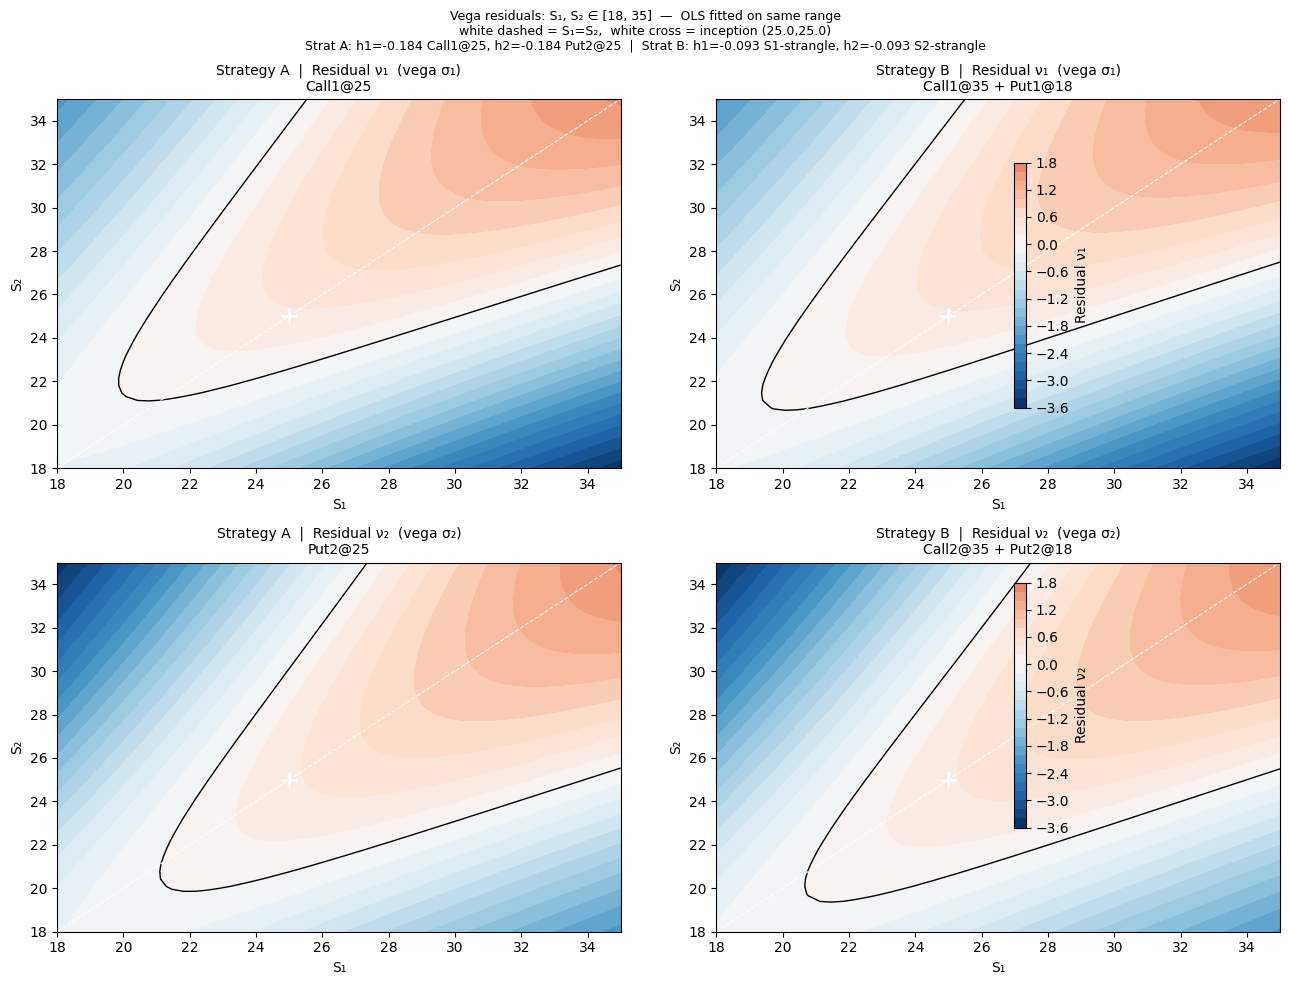

In [23]:
# ── Extra Greeks: Put on S1, Call on S2 ──────────────────────────────────────

def _p1_gk(S1, K):
    """BS put on S1 Greeks — vectorised (delta1, gamma11, vega1)."""
    d1 = (np.log(S1/K) + (r + 0.5*sigma1**2)*T) / (sigma1*_sqT)
    np1 = _Np(d1)
    return {"d1": _N(d1) - 1., "g11": np1/(S1*sigma1*_sqT), "v1": S1*np1*_sqT}

def _c2_gk(S2, K):
    """BS call on S2 Greeks — vectorised (delta2, gamma22, vega2)."""
    d1 = (np.log(S2/K) + (r + 0.5*sigma2**2)*T) / (sigma2*_sqT)
    np1 = _Np(d1)
    return {"d2": _N(d1), "g22": np1/(S2*sigma2*_sqT), "v2": S2*np1*_sqT}

# ── OLS fitting grid: S1, S2 ∈ [18, 35] ─────────────────────────────────────
N_CMP = 30
s1_c  = np.linspace(18, 35, N_CMP);  s2_c = np.linspace(18, 35, N_CMP)
S1c, S2c = np.meshgrid(s1_c, s2_c);  s1cf, s2cf = S1c.ravel(), S2c.ravel()

sp_c = _sp_gk(s1cf, s2cf)

# Strategy A instruments on the fitting grid
c1a_c = _c1_gk(s1cf, 25.)          # Call1@25
p2a_c = _p2_gk(s2cf, 25.)          # Put2@25

# Strategy B instruments on the fitting grid (strangles)
s1_leg_d = _c1_gk(s1cf, 35.)["d1"]  + _p1_gk(s1cf, 18.)["d1"]   # Call1@35 + Put1@18
s1_leg_g = _c1_gk(s1cf, 35.)["g11"] + _p1_gk(s1cf, 18.)["g11"]
s1_leg_v = _c1_gk(s1cf, 35.)["v1"]  + _p1_gk(s1cf, 18.)["v1"]

s2_leg_d = _c2_gk(s2cf, 35.)["d2"]  + _p2_gk(s2cf, 18.)["d2"]   # Call2@35 + Put2@18
s2_leg_g = _c2_gk(s2cf, 35.)["g22"] + _p2_gk(s2cf, 18.)["g22"]
s2_leg_v = _c2_gk(s2cf, 35.)["v2"]  + _p2_gk(s2cf, 18.)["v2"]

# ── Solve OLS for each strategy (same _ols_pair / sc_* as before) ─────────────
h1a, nF1a = _ols_pair(sp_c["d1"], sp_c["g11"], sp_c["v1"], c1a_c["d1"],  c1a_c["g11"],  c1a_c["v1"])
h2a, nF2a = _ols_pair(sp_c["d2"], sp_c["g22"], sp_c["v2"], p2a_c["d2"],  p2a_c["g22"],  p2a_c["v2"])

h1b, nF1b = _ols_pair(sp_c["d1"], sp_c["g11"], sp_c["v1"], s1_leg_d, s1_leg_g, s1_leg_v)
h2b, nF2b = _ols_pair(sp_c["d2"], sp_c["g22"], sp_c["v2"], s2_leg_d, s2_leg_g, s2_leg_v)

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for label, h1, nF1, h2, nF2 in [("A (ATM)", h1a, nF1a, h2a, nF2a),
                                  ("B (OTM strangle)", h1b, nF1b, h2b, nF2b)]:
    c1_v0 = float(np.squeeze(_c1_gk(S1_0, 25.)["v1"]))
    p2_v0 = float(np.squeeze(_p2_gk(S2_0, 25.)["v2"]))
    s1l_v0 = float(np.squeeze(_c1_gk(S1_0,35.)["v1"])) + float(np.squeeze(_p1_gk(S1_0,18.)["v1"]))
    s2l_v0 = float(np.squeeze(_c2_gk(S2_0,35.)["v2"])) + float(np.squeeze(_p2_gk(S2_0,18.)["v2"]))

    if label.startswith("A"):
        res_v1 = g0["v1"] + h1*c1_v0
        res_v2 = g0["v2"] + h2*p2_v0
    else:
        res_v1 = g0["v1"] + h1*s1l_v0
        res_v2 = g0["v2"] + h2*s2l_v0
    rows.append({"Strategy": label, "h1": h1, "nF1": nF1, "h2": h2, "nF2": nF2,
                 "res ν₁@inception": res_v1, "res ν₂@inception": res_v2})

print("OLS hedge ratios (fitting range S1,S2 ∈ [18, 35]):")
print(pd.DataFrame(rows).set_index("Strategy").to_string(float_format="{:+.4f}".format))

# ── Fine plot grid [18, 35] ───────────────────────────────────────────────────
N_FP = 50
s1_f, s2_f  = np.linspace(18, 35, N_FP), np.linspace(18, 35, N_FP)
S1F, S2F    = np.meshgrid(s1_f, s2_f)
s1ff, s2ff  = S1F.ravel(), S2F.ravel()

sp_f = _sp_gk(s1ff, s2ff)

# Vega of each instrument on the fine grid
v1_c1a25  = _c1_gk(s1ff, 25.)["v1"]
v2_p2a25  = _p2_gk(s2ff, 25.)["v2"]
v1_s1_b   = _c1_gk(s1ff, 35.)["v1"] + _p1_gk(s1ff, 18.)["v1"]
v2_s2_b   = _c2_gk(s2ff, 35.)["v2"] + _p2_gk(s2ff, 18.)["v2"]

# Residual vegas
V1A = (sp_f["v1"] + h1a * v1_c1a25).reshape(N_FP, N_FP)
V2A = (sp_f["v2"] + h2a * v2_p2a25).reshape(N_FP, N_FP)
V1B = (sp_f["v1"] + h1b * v1_s1_b ).reshape(N_FP, N_FP)
V2B = (sp_f["v2"] + h2b * v2_s2_b ).reshape(N_FP, N_FP)

# ── Plot: 2 rows (ν₁, ν₂) × 2 cols (A, B), shared colour scale per row ──────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

def _heatmap(ax, Z, title, vm, cmap="RdBu_r"):
    cf = ax.contourf(S1F, S2F, Z, levels=30, cmap=cmap, vmin=-vm, vmax=vm)
    ax.contour(S1F, S2F, Z, levels=[0], colors="k", linewidths=1.0)
    ax.plot([18, 35], [18, 35], "w--", lw=0.8)
    ax.plot(S1_0, S2_0, "w+", ms=12, mew=2.0)
    ax.set_xlabel("S₁");  ax.set_ylabel("S₂")
    ax.set_title(title, fontsize=10)
    return cf

# Shared scale per row
vm1 = max(np.abs(V1A).max(), np.abs(V1B).max())
vm2 = max(np.abs(V2A).max(), np.abs(V2B).max())

cf00 = _heatmap(axes[0,0], V1A, "Strategy A  |  Residual ν₁  (vega σ₁)\nCall1@25", vm1)
cf01 = _heatmap(axes[0,1], V1B, "Strategy B  |  Residual ν₁  (vega σ₁)\nCall1@35 + Put1@18", vm1)
cf10 = _heatmap(axes[1,0], V2A, "Strategy A  |  Residual ν₂  (vega σ₂)\nPut2@25", vm2)
cf11 = _heatmap(axes[1,1], V2B, "Strategy B  |  Residual ν₂  (vega σ₂)\nCall2@35 + Put2@18", vm2)

fig.colorbar(cf00, ax=axes[0,:].tolist(), shrink=0.7, label="Residual ν₁")
fig.colorbar(cf10, ax=axes[1,:].tolist(), shrink=0.7, label="Residual ν₂")

plt.suptitle(
    f"Vega residuals: S₁, S₂ ∈ [18, 35]  —  OLS fitted on same range\n"
    f"white dashed = S₁=S₂,  white cross = inception ({S1_0},{S2_0})\n"
    f"Strat A: h1={h1a:+.3f} Call1@25, h2={h2a:+.3f} Put2@25  |  "
    f"Strat B: h1={h1b:+.3f} S1-strangle, h2={h2b:+.3f} S2-strangle",
    fontsize=9
)
plt.tight_layout()
plt.show()


In [24]:
# ── Initial option costs at inception (S1=S2=25, futures carry zero premium) ─

pr_spread = float(np.squeeze(_sp_price(S1_0, S2_0)))   # spread option premium

# Strategy A: Call1@25 + Put2@25
pr_c1_25  = float(np.squeeze(_c1_price(S1_0, 25.)))
pr_p2_25  = float(np.squeeze(_p2_price(S2_0, 25.)))

# Strategy B: (Call1@35 + Put1@18) on S1,  (Call2@35 + Put2@18) on S2
pr_c1_35  = bs_call_price(S1_0, 35., sigma1, T, r)
pr_p1_18  = bs_put_price( S1_0, 18., sigma1, T, r)
pr_c2_35  = bs_call_price(S2_0, 35., sigma2, T, r)
pr_p2_18  = bs_put_price( S2_0, 18., sigma2, T, r)

leg1_A = h1a * pr_c1_25
leg2_A = h2a * pr_p2_25
leg1_B = h1b * (pr_c1_35 + pr_p1_18)
leg2_B = h2b * (pr_c2_35 + pr_p2_18)

cost_df = pd.DataFrame({
    "Strategy A": [pr_spread, leg1_A, leg2_A, pr_spread + leg1_A + leg2_A],
    "Strategy B": [pr_spread, leg1_B, leg2_B, pr_spread + leg1_B + leg2_B],
}, index=["Spread option (long)", "h1 × S1-leg", "h2 × S2-leg", "Net portfolio cost"])

print("Initial option costs at inception  (S1=S2=25, futures = 0 premium)\n")
print(cost_df.to_string(float_format="{:+.4f}".format))

print(f"\nS1-leg detail:")
print(f"  A: {h1a:+.4f} × Call1@25  (price={pr_c1_25:.4f})               = {leg1_A:+.4f}")
print(f"  B: {h1b:+.4f} × [Call1@35 ({pr_c1_35:.4f}) + Put1@18 ({pr_p1_18:.4f})] = {leg1_B:+.4f}")

print(f"\nS2-leg detail:")
print(f"  A: {h2a:+.4f} × Put2@25   (price={pr_p2_25:.4f})               = {leg2_A:+.4f}")
print(f"  B: {h2b:+.4f} × [Call2@35 ({pr_c2_35:.4f}) + Put2@18 ({pr_p2_18:.4f})] = {leg2_B:+.4f}")


Initial option costs at inception  (S1=S2=25, futures = 0 premium)

                      Strategy A  Strategy B
Spread option (long)     +4.4505     +4.4505
h1 × S1-leg              -2.4050     -1.7675
h2 × S2-leg              -2.4050     -1.7675
Net portfolio cost       -0.3594     +0.9154

S1-leg detail:
  A: -0.1839 × Call1@25  (price=13.0808)               = -2.4050
  B: -0.0927 × [Call1@35 (11.0606) + Put1@18 (7.9981)] = -1.7675

S2-leg detail:
  A: -0.1839 × Put2@25   (price=13.0808)               = -2.4050
  B: -0.0927 × [Call2@35 (11.0606) + Put2@18 (7.9981)] = -1.7675


Hedge quality scores  (S1, S2 ∈ [18, 35], lower RMSE / efficiency = better)

             rmse_ν1   rmse_ν2  rmse_total    max_ν1    max_ν2  net_cost  efficiency
Strategy                                                                            
Strategy A +0.999620 +0.999620   +1.999239 +3.541608 +3.541608 -0.359424   +5.562349
Strategy B +0.997573 +0.997573   +1.995146 +3.585132 +3.585132 +0.915426   +2.179473

Winner per metric:
  RMSE ν₁        A=+0.9996 ████████████████████  B=+0.9976 ███████████████████   → winner: B
  RMSE ν₂        A=+0.9996 ████████████████████  B=+0.9976 ███████████████████   → winner: B
  RMSE total     A=+1.9992 ████████████████████  B=+1.9951 ███████████████████   → winner: B
  Max |ν₁|       A=+3.5416 ███████████████████   B=+3.5851 ███████████████████   → winner: A
  Max |ν₂|       A=+3.5416 ███████████████████   B=+3.5851 ███████████████████   → winner: A
  Net cost       A=-0.3594 ███████               B=+0.9154 ████████████████████  → winner: A
  Eff

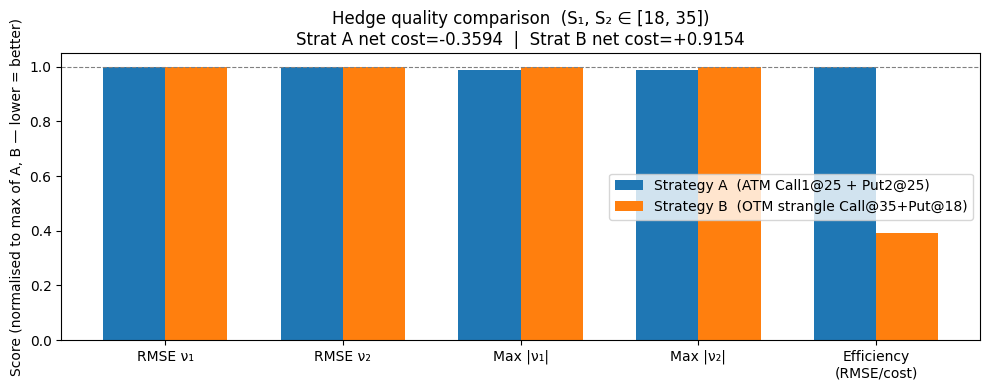

In [25]:
# ── Hedge quality scoring over S1, S2 ∈ [18, 35] ────────────────────────────
# V1A, V2A, V1B, V2B already computed on the N_FP×N_FP fine grid

net_cost_A = pr_spread + leg1_A + leg2_A
net_cost_B = pr_spread + leg1_B + leg2_B

def _score(V1, V2, net_cost):
    rmse_v1  = float(np.sqrt(np.mean(V1**2)))
    rmse_v2  = float(np.sqrt(np.mean(V2**2)))
    max_v1   = float(np.abs(V1).max())
    max_v2   = float(np.abs(V2).max())
    rmse_tot = rmse_v1 + rmse_v2          # combined vega residual
    eff      = rmse_tot / abs(net_cost)   # residual per dollar: lower = better
    return dict(
        rmse_ν1   = rmse_v1,
        rmse_ν2   = rmse_v2,
        rmse_total= rmse_tot,
        max_ν1    = max_v1,
        max_ν2    = max_v2,
        net_cost  = net_cost,
        efficiency= eff,
    )

sc_A = _score(V1A, V2A, net_cost_A)
sc_B = _score(V1B, V2B, net_cost_B)

score_df = pd.DataFrame({"Strategy A": sc_A, "Strategy B": sc_B}).T
score_df.index.name = "Strategy"

# highlight winner per column
def _fmt(v): return f"{v:+.4f}"

print("Hedge quality scores  (S1, S2 ∈ [18, 35], lower RMSE / efficiency = better)\n")
print(score_df.to_string(float_format="{:+.6f}".format))

# ── Winner summary ────────────────────────────────────────────────────────────
print("\nWinner per metric:")
metrics = {
    "RMSE ν₁"    : ("rmse_ν1",    "lower"),
    "RMSE ν₂"    : ("rmse_ν2",    "lower"),
    "RMSE total" : ("rmse_total", "lower"),
    "Max |ν₁|"   : ("max_ν1",     "lower"),
    "Max |ν₂|"   : ("max_ν2",     "lower"),
    "Net cost"   : ("net_cost",   "lower"),
    "Efficiency" : ("efficiency", "lower"),
}
for label, (key, direction) in metrics.items():
    a, b = sc_A[key], sc_B[key]
    winner = "A" if (a < b) else ("B" if b < a else "tie")
    bar_a = "█" * int(20 * abs(a) / max(abs(a), abs(b), 1e-12))
    bar_b = "█" * int(20 * abs(b) / max(abs(a), abs(b), 1e-12))
    print(f"  {label:<14} A={a:+.4f} {bar_a:<20}  B={b:+.4f} {bar_b:<20}  → winner: {winner}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
metrics_plot = ["rmse_ν1", "rmse_ν2", "max_ν1", "max_ν2", "efficiency"]
labels_plot  = ["RMSE ν₁", "RMSE ν₂", "Max |ν₁|", "Max |ν₂|", "Efficiency\n(RMSE/cost)"]

vals_A = [sc_A[m] for m in metrics_plot]
vals_B = [sc_B[m] for m in metrics_plot]

# Normalise each metric to max(A,B) so bars are comparable across metrics
norms  = [max(abs(a), abs(b), 1e-12) for a, b in zip(vals_A, vals_B)]
vals_A_n = [v/n for v, n in zip(vals_A, norms)]
vals_B_n = [v/n for v, n in zip(vals_B, norms)]

x = np.arange(len(metrics_plot))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, vals_A_n, w, label="Strategy A  (ATM Call1@25 + Put2@25)", color="C0")
ax.bar(x + w/2, vals_B_n, w, label="Strategy B  (OTM strangle Call@35+Put@18)", color="C1")
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels_plot)
ax.set_ylabel("Score (normalised to max of A, B — lower = better)")
ax.set_title(f"Hedge quality comparison  (S₁, S₂ ∈ [18, 35])\n"
             f"Strat A net cost={net_cost_A:+.4f}  |  Strat B net cost={net_cost_B:+.4f}")
ax.legend()
plt.tight_layout()
plt.show()


## Notes

- This notebook assumes **risk-neutral GBM** with constant volatilities and constant correlation.
- For a first pass, that is usually the cleanest benchmark against a Kirk approximation.
- If you later want a more market-specific setup, the next steps would be:
  - include individual carries / forwards rather than simple spot growth at `r`
  - switch from spot inputs to forward inputs directly
  - simulate along time steps rather than terminal-only
  - add Greeks
  - compare with Margrabe when `K = 0`
  - calibrate against implied spread vol or listed option prices
